## Loading Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, make_scorer, accuracy_score
from sklearn.pipeline import Pipeline

## Data loading

In [2]:
train = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv')
test = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv')

# Exploratory Data Analysis (EDA)

In [3]:
# To view all columns
pd.set_option('display.max_columns', None)

# Top five rows
train.head(5)

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,userId,trafficSource.campaign,device.mobileDeviceMarketingName,geoNetwork.networkDomain,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,geoNetwork.region,trafficSource,totals.visits,geoNetwork.networkLocation,sessionId,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,browserMajor,locationCountry,device.browserSize,trafficSource.adwordsClickInfo.adNetworkType,socialEngagementType,geoNetwork.city,trafficSource.adwordsClickInfo.page,geoNetwork.metro,pageViews,locationZone,device.mobileDeviceModel,trafficSource.referralPath,totals.bounces,date,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,61421,(not set),not available in demo dataset,domain1,0,not available in demo dataset,1,not available in demo dataset,Washington,youtube.com,1,not available in demo dataset,1500100799,Windows,Northern America,referral,NaN,not available in demo dataset,United States,not available in demo dataset,NaN,Not Socially Engaged,Redmond,NaN,Seattle-Tacoma WA,1.0,8,not available in demo dataset,/intl/hr/yt/about/,1.0,20170714,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1500100799,Americas,False,1.0
1,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,72287,(not set),not available in demo dataset,domain3,0,not available in demo dataset,1,not available in demo dataset,California,(direct),1,not available in demo dataset,1495262065,Macintosh,Northern America,(none),NaN,not available in demo dataset,United States,not available in demo dataset,NaN,Not Socially Engaged,Mountain View,NaN,San Francisco-Oakland-San Jose CA,1.0,8,not available in demo dataset,NaN,1.0,20170519,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1495262065,Americas,False,1.0
2,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,25180,(not set),not available in demo dataset,domain1,0,not available in demo dataset,2,not available in demo dataset,Lombardy,google,1,not available in demo dataset,1508510328,Windows,Southern Europe,organic,NaN,not available in demo dataset,Italy,not available in demo dataset,NaN,Not Socially Engaged,Milan,NaN,(not set),6.0,8,not available in demo dataset,NaN,NaN,20171020,not available in demo dataset,desktop,Organic Search,not available in demo dataset,6,not available in demo dataset,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,not available in demo dataset,41295,(not set),not available in demo dataset,domain3,0,not available in demo dataset,1,not available in demo dataset,not available in demo dataset,youtube.com,1,not available in demo dataset,1483431838,Windows,Eastern Asia,referral,NaN,not available in demo dataset,Japan,not available in demo dataset,NaN,Not Socially Engaged,not available in demo dataset,NaN,not available in demo dataset,1.0,8,not available in demo dataset,/yt/about/ja/,1.0,20170103,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,113697,(not set),not available in demo dataset,domain1,0,not available 

# Sanity checking

## Compute overlap distribution

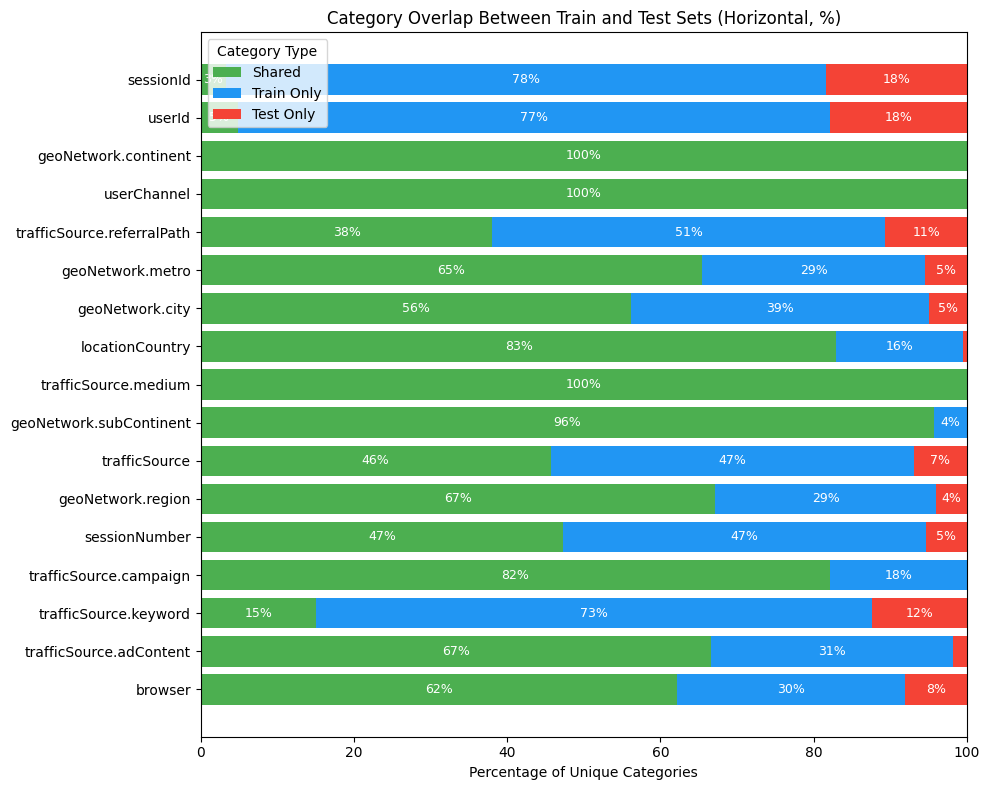

In [4]:
def category_overlap_distribution(train_df, test_df, categorical_cols):
    result = []

    for col in categorical_cols:
        train_unique = set(train_df[col].dropna().unique())
        test_unique = set(test_df[col].dropna().unique())

        shared = train_unique & test_unique
        train_only = train_unique - test_unique
        test_only = test_unique - train_unique

        total = len(shared) + len(train_only) + len(test_only)
        result.append({
            'feature': col,
            'Shared': len(shared),
            'Train Only': len(train_only),
            'Test Only': len(test_only),
            'Total': total
        })

    return pd.DataFrame(result)
    
# Apply function
categorical_cols = [
    'browser','trafficSource.adContent','trafficSource.keyword','trafficSource.campaign',
    'sessionNumber','geoNetwork.region','trafficSource','geoNetwork.subContinent',
    'trafficSource.medium','locationCountry','geoNetwork.city','geoNetwork.metro',
    'trafficSource.referralPath','userChannel','geoNetwork.continent','userId','sessionId']

overlap_df = category_overlap_distribution(train, test, categorical_cols)

# Normalize for percentage stacking
percentage_df = overlap_df.copy()
for col in ['Shared', 'Train Only', 'Test Only']:
    percentage_df[col] = (percentage_df[col] / percentage_df['Total']) * 100

# Plot horizontal stacked bar with percentage labels
fig1, ax1 = plt.subplots(figsize=(10, 8))

bottom = [0] * len(percentage_df)
colors = {'Shared': '#4CAF50', 'Train Only': '#2196F3', 'Test Only': '#F44336'}

for cat in ['Shared', 'Train Only', 'Test Only']:
    ax1.barh(percentage_df['feature'], percentage_df[cat], left=bottom, label=cat, color=colors[cat])
    for i, (val, b) in enumerate(zip(percentage_df[cat], bottom)):
        if val > 2:  
            ax1.text(b + val / 2, i, f"{val:.0f}%", va='center', ha='center', color='white', fontsize=9)
    bottom = [i + j for i, j in zip(bottom, percentage_df[cat])]

ax1.set_xlabel("Percentage of Unique Categories")
ax1.set_title("Category Overlap Between Train and Test Sets (Horizontal, %)")
ax1.legend(title="Category Type", loc="upper left")
plt.tight_layout()
plt.savefig("Category Overlap Between Train and Test Sets.png", dpi=300, bbox_inches="tight")
plt.show()

## Checking for duplicates column wise

In [5]:
dupe = train.T.duplicated(keep=False)
dupe_cols = train.columns[dupe]
print("The columns having duplicate values :", dupe_cols)

The columns having duplicate values : Index(['device.screenResolution', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'device.mobileDeviceMarketingName',
       'device.operatingSystemVersion', 'device.flashVersion',
       'geoNetwork.networkLocation', 'browserMajor', 'device.browserSize',
       'device.mobileDeviceModel', 'device.language', 'device.browserVersion',
       'device.screenColors'],
      dtype='object')


In [6]:
dupe = test.T.duplicated(keep=False)
dupe_cols = test.columns[dupe]
print("The columns having duplicate values :", dupe_cols)

The columns having duplicate values : Index(['device.browserSize', 'device.browserVersion', 'device.flashVersion',
       'device.language', 'device.mobileDeviceBranding',
       'device.mobileDeviceMarketingName', 'device.mobileDeviceModel',
       'device.mobileInputSelector', 'device.operatingSystemVersion',
       'device.screenColors', 'device.screenResolution',
       'geoNetwork.networkLocation', 'browserMajor'],
      dtype='object')


In [7]:
# Printing them as a df
train[['device.screenResolution','device.mobileDeviceBranding',
       'device.mobileInputSelector','device.mobileDeviceMarketingName',
       'device.operatingSystemVersion','device.flashVersion',
       'geoNetwork.networkLocation','browserMajor','device.browserSize',
       'device.mobileDeviceModel','device.language','device.browserVersion',
       'device.screenColors']]

,device.screenResolution,device.mobileDeviceBranding,device.mobileInputSelector,device.mobileDeviceMarketingName,device.operatingSystemVersion,device.flashVersion,geoNetwork.networkLocation,browserMajor,device.browserSize,device.mobileDeviceModel,device.language,device.browserVersion,device.screenColors
0,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset
1,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset
2,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset
3,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset
4,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116018,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset
116019,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset
116020,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset
116021,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset,not available in demo dataset


## Creating a custom transformer and dropping the duplicate columns (Since they don't help much in model)


In [8]:
# Custom function to drop all the duplicate colums using a placeholder

class DropOnlyPlaceholderColumns(BaseEstimator, TransformerMixin):
    def __init__(self, placeholder="not available in demo dataset"):
        self.placeholder = placeholder
        self.cols_to_drop_ = []

    def fit(self, X, y=None):
        self.cols_to_drop_ = [
            col for col in X.columns
            if (X[col].nunique() == 1 and X[col].dropna().unique()[0] == self.placeholder)
        ]
        return self

    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, errors='ignore')

In [9]:
# Pipeline
pipeline = Pipeline([
    ('drop_useless', DropOnlyPlaceholderColumns())
])

# Fitting on training set
train_v1 = pipeline.fit_transform(train)

# Same transformation to the test set
test_v1 = pipeline.transform(test)

## Handling columns with only one unique value

In [10]:
# Analysing the object column using describe
train_v1.select_dtypes(include='object').describe()

,trafficSource.isTrueDirect,browser,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,trafficSource.campaign,geoNetwork.networkDomain,geoNetwork.region,trafficSource,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,locationCountry,trafficSource.adwordsClickInfo.adNetworkType,socialEngagementType,geoNetwork.city,geoNetwork.metro,trafficSource.referralPath,deviceType,userChannel,geoNetwork.continent
count,42890,116023,2963,44162,116023,116023,4281,116023,116023,116023,116023,116023,116023,116023,4281,116023,4281,116023,116023,116023,42714,116023,116023,116023
unique,1,34,53,566,1,5,3,28,3,388,161,18,23,7,1,193,2,1,695,104,941,3,8,6
top,True,Chrome,Google Merchandise Store,(not provided),medium,Region_2,Top,(not set),domain1,not available in demo dataset,google,Windows,Northern America,organic,False,United States,Google Search,Not Socially Engaged,not available in demo dataset,not available in demo dataset,/,desktop,Organic Search,Americas
freq,42890,84508,1410,39066,116023,23294,2721,110280,38795,60138,44332,39135,63596,40654,4281,60369,2784,116023,60138,60138,17970,86480,46925,69856


In [11]:
# Find columns with only one unique value
constant_cols = [col for col in train_v1.columns if train_v1[col].nunique() == 1]
constant_cols

['trafficSource.isTrueDirect',
 'screenSize',
 'totals.visits',
 'trafficSource.adwordsClickInfo.isVideoAd',
 'socialEngagementType',
 'locationZone',
 'totals.bounces',
 'new_visits']

In [12]:
# Dropping some and keeping the remaining
train_v2 = train_v1.drop(columns=['screenSize','socialEngagementType','locationZone','geoNetwork.region',
                                  'geoNetwork.metro','date'])
test_v2 = test_v1.drop(columns=['screenSize','socialEngagementType','locationZone','geoNetwork.region',
                                'geoNetwork.metro','date'])

In [13]:
# Shape
train_v2.shape

(116023, 33)

## Summary stats

In [14]:
train_v2.describe()

,purchaseValue,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,totals.bounces,totalHits,sessionStart,new_visits
count,1.160230e+05,116023.000000,116023.000000,116023.000000,116023.0,1.160230e+05,4281.000000,116015.000000,47148.0,116023.000000,1.160230e+05,80518.0
mean,2.656393e+07,61094.356231,0.037019,2.691311,1.0,1.493429e+09,1.019622,8.412352,1.0,10.607371,1.493429e+09,1.0
std,2.051825e+08,35240.756859,0.188808,10.451613,0.0,1.528798e+07,0.174517,14.344937,0.0,19.629576,1.528798e+07,0.0
min,0.000000e+00,0.000000,0.000000,1.000000,1.0,1.470035e+09,1.000000,1.000000,1.0,1.000000,1.470035e+09,1.0
25%,0.000000e+00,30603.500000,0.000000,1.000000,1.0,1.480066e+09,1.000000,1.000000,1.0,1.000000,1.480066e+09,1.0
50%,0.000000e+00,61014.000000,0.000000,1.000000,1.0,1.491646e+09,1.000000,2.000000,1.0,2.000000,1.491646e+09,1.0
75%,0.000000e+00,91616.500000,0.000000,2.000000,1.0,1.505079e+09,1.000000,10.000000,1.0,12.000000,1.505079e+09,1.0
max,2.312950e+10,122276.000000,1.000000,447.000000,1.0,1.525157e+09,5.000000,469.000000,1.0,500.000000,1.525157e+09,1.0


In [15]:
#Info (Features and dtypes)
train_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 33 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   trafficSource.adContent                       2963 non-null    object 
 4   trafficSource.keyword                         44162 non-null   object 
 5   geoCluster                                    116023 non-null  object 
 6   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 7   userId                                        116023 non-null  int64  
 8   trafficSource.campaign                        116023 non-null  object 
 9   geoNetwork.networkDomain                      11

In [16]:
# Missing values in train df
train_v2.isnull().sum()

trafficSource.isTrueDirect                       73133
purchaseValue                                        0
browser                                              0
trafficSource.adContent                         113060
trafficSource.keyword                            71861
geoCluster                                           0
trafficSource.adwordsClickInfo.slot             111742
userId                                               0
trafficSource.campaign                               0
geoNetwork.networkDomain                             0
gclIdPresent                                         0
sessionNumber                                        0
trafficSource                                        0
totals.visits                                        0
sessionId                                            0
os                                                   0
geoNetwork.subContinent                              0
trafficSource.medium                                 0
trafficSou

In [17]:
# Percentage of the missing values (Train)
missing_perc = train_v2.isnull().sum()/train_v2.shape[0]*100
missing_perc

trafficSource.isTrueDirect                      63.033192
purchaseValue                                    0.000000
browser                                          0.000000
trafficSource.adContent                         97.446196
trafficSource.keyword                           61.936857
geoCluster                                       0.000000
trafficSource.adwordsClickInfo.slot             96.310214
userId                                           0.000000
trafficSource.campaign                           0.000000
geoNetwork.networkDomain                         0.000000
gclIdPresent                                     0.000000
sessionNumber                                    0.000000
trafficSource                                    0.000000
totals.visits                                    0.000000
sessionId                                        0.000000
os                                               0.000000
geoNetwork.subContinent                          0.000000
trafficSource.

In [18]:
# Percentage of the missing values (Test)
missing_perc = test_v2.isnull().sum()/test_v2.shape[0]*100
missing_perc

userChannel                                      0.000000
browser                                          0.000000
deviceType                                       0.000000
device.isMobile                                  0.000000
os                                               0.000000
geoNetwork.city                                  0.000000
geoNetwork.continent                             0.000000
locationCountry                                  0.000000
geoNetwork.networkDomain                         0.000000
geoNetwork.subContinent                          0.000000
totals.bounces                                  59.553196
totalHits                                        0.000000
new_visits                                      30.724678
pageViews                                        0.010343
totals.visits                                    0.000000
trafficSource.adContent                         97.383300
trafficSource.adwordsClickInfo.adNetworkType    96.183548
trafficSource.

### We cud see that the missing ratio is same in both aprox.

## Before

In [19]:
tr_sources = train_v2[['userChannel','trafficSource','trafficSource.medium','trafficSource.adwordsClickInfo.page',
                   'trafficSource.adwordsClickInfo.adNetworkType','trafficSource.campaign',
                   'trafficSource.adContent','trafficSource.keyword','trafficSource.referralPath','purchaseValue']]

# Keep rows with at least 6 non-null values
tr_sources_clean_1 = tr_sources[tr_sources.notna().sum(axis=1) >= 6]

display(tr_sources_clean_1)

,userChannel,trafficSource,trafficSource.medium,trafficSource.adwordsClickInfo.page,trafficSource.adwordsClickInfo.adNetworkType,trafficSource.campaign,trafficSource.adContent,trafficSource.keyword,trafficSource.referralPath,purchaseValue
0,Social,youtube.com,referral,NaN,NaN,(not set),NaN,NaN,/intl/hr/yt/about/,0.0
2,Organic Search,google,organic,NaN,NaN,(not set),NaN,(not provided),NaN,0.0
3,Social,youtube.com,referral,NaN,NaN,(not set),NaN,NaN,/yt/about/ja/,0.0
5,Referral,(direct),(none),NaN,NaN,(not set),NaN,NaN,/,28000000.0
6,Referral,(direct),(none),NaN,NaN,(not set),NaN,NaN,/,80510000.0
...,...,...,...,...,...,...,...,...,...,...
116017,Referral,analytics.google.com,referral,NaN,NaN,(not set),NaN,NaN,/analytics/web/,0.0
116018,Referral,(direct),(none),NaN,NaN,(not set),NaN,NaN,/,35180000.0
116020,Referral,seroundtable.com,referral,NaN,NaN,(not set),NaN,NaN,/google-analytics-launches-public-demo-account...,0.0
116021,Organic Search,google,organic,NaN,NaN,(not set),NaN,(not provided),NaN,0.0


## Filling the pageViews column with mode in train and test set

In [20]:
# Fill missing pageviews in train using train's mode
train_mode = train_v2['pageViews'].mode()[0]
train_v2['pageViews'] = train_v2['pageViews'].fillna(train_mode)

# Fill missing pageviews in test using test's mode
test_mode = test_v2['pageViews'].mode()[0]
test_v2['pageViews'] = test_v2['pageViews'].fillna(test_mode)

# Feature Engineering

### Changing trafficSource = '(direct)' to 'root' if referralPath = '/'.

In [21]:
def transform_direct_to_root(df):

    df_copy = df.copy()
    condition = (
        (df_copy['trafficSource'] == '(direct)') &
        (df_copy['trafficSource.referralPath'] == '/')
    )
    df_copy.loc[condition, 'trafficSource'] = 'root'
    return df_copy

train_v3 = transform_direct_to_root(train_v2)
test_v3 = transform_direct_to_root(test_v2)

### Changing trafficSource.medium = '((root_refe))' if its '(none)', trafficSource = 'root' and referralPath = '/'.

In [22]:
def fix_medium_root(df):
    df_copy = df.copy()

    condition = (
        (df_copy['trafficSource'] == 'root') &
        (df_copy['trafficSource.medium'] == '(none)')
    )

    df_copy.loc[condition, 'trafficSource.medium'] = '(root_refe)'
    return df_copy

train_v4 = fix_medium_root(train_v3)
test_v4 = fix_medium_root(test_v3)

### Converts '(none)' medium to '(direct)' for truly direct traffic sessions


In [23]:
def fix_medium_direct(df):
    df_copy = df.copy()

    condition = (
        (df_copy['userChannel'] == 'Direct') &
        (df_copy['trafficSource'] == '(direct)') &
        (df_copy['trafficSource.medium'] == '(none)')
    )

    df_copy.loc[condition, 'trafficSource.medium'] = '(direct)'
    return df_copy

train_v5 = fix_medium_direct(train_v4)
test_v5 = fix_medium_direct(test_v4)

### Fixes mislabeled '(none)' mediums by assigning 'paidsearch' or 'organicsearch' based on userChannel


In [24]:
def fix_medium_search(df):
    df_copy = df.copy()

    condition_1 = (
        (df_copy['userChannel'] == 'Paid Search') &
        (df_copy['trafficSource'] == '(direct)') &
        (df_copy['trafficSource.medium'] == '(none)')
    )
    condition_2 = (
        (df_copy['userChannel'] == 'Organic Search') &
        (df_copy['trafficSource'] == '(direct)') &
        (df_copy['trafficSource.medium'] == '(none)')
    )
    df_copy.loc[condition_1, 'trafficSource.medium'] = 'paidsearch'
    df_copy.loc[condition_2, 'trafficSource.medium'] = 'organicsearch'

    return df_copy

train_v6 = fix_medium_search(train_v5)
test_v6 = fix_medium_search(test_v5)

### If userChannel is 'Referral', trafficSource is '(direct)', and medium is '(none)', then: Set medium to 'referral', Set trafficSource to the full referralPath (without leading '/')

In [25]:
def fix_referral_channel(df):

    df_copy = df.copy()

    condition = (
        (df_copy['userChannel'] == 'Referral') &
        (df_copy['trafficSource'] == '(direct)') &
        (df_copy['trafficSource.medium'] == '(none)') &
        (df_copy['trafficSource.referralPath'].notna())
    )

    # Remove leading "/" from referralPath and assign to trafficSource
    df_copy.loc[condition, 'trafficSource'] = (
        df_copy.loc[condition, 'trafficSource.referralPath']
        .str.lstrip('/')
        .fillna('unknown')
    )

    # Set medium to 'referral'
    df_copy.loc[condition, 'trafficSource.medium'] = 'referral'

    return df_copy

train_v7 = fix_referral_channel(train_v6)
test_v7 = fix_referral_channel(test_v6)

In [26]:
def fill_visits_with_source_frequency(train_df, test_df, source_col='trafficSource', target_col='totals.visits'):
    """
    Replace the 'totals.visits' column with the frequency (count) of each 'trafficSource' 
    based on the training data. Applies to both train and test.
    """
    # Step 1: Compute frequency counts from training data
    source_counts = train_df[source_col].value_counts().to_dict()
    
    # Step 2: Copy to avoid modifying originals
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Step 3: Impute visits in train and test using traffic source counts
    train_df[target_col] = train_df[source_col].map(source_counts).fillna(0).astype(int)
    test_df[target_col] = test_df[source_col].map(source_counts).fillna(0).astype(int)

    return train_df, test_df

train_v8, test_v8 = fill_visits_with_source_frequency(train_v7, test_v7)

# Visualising

### Plot 1 (Total Purchase Value by User Channel)

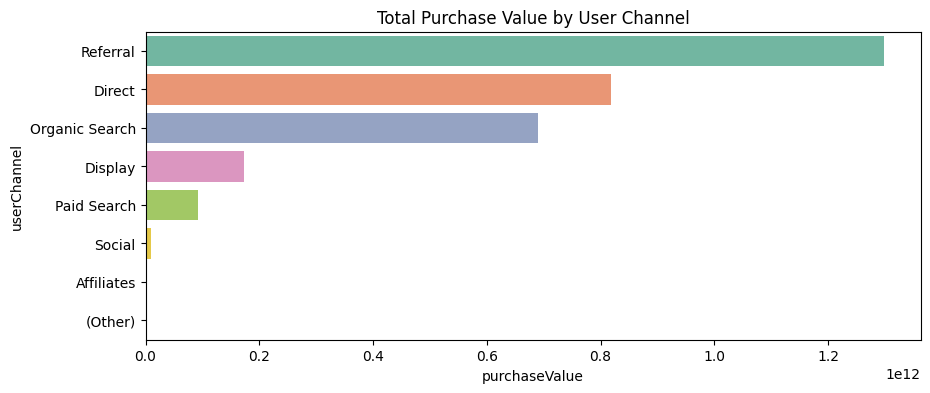

In [27]:
fig1, ax1 = plt.subplots(figsize=(10, 4))
user_channel = train_v8.groupby('userChannel')['purchaseValue'].sum().reset_index().sort_values(by='purchaseValue', ascending=False)
sns.barplot(data=user_channel, x='purchaseValue', y='userChannel', ax=ax1, palette='Set2')
ax1.set_title('Total Purchase Value by User Channel')
fig1.savefig("purchase_by_user_channel.png", dpi=300, bbox_inches="tight")

### Plot 2 (Total Purchase Value by trafficSource)

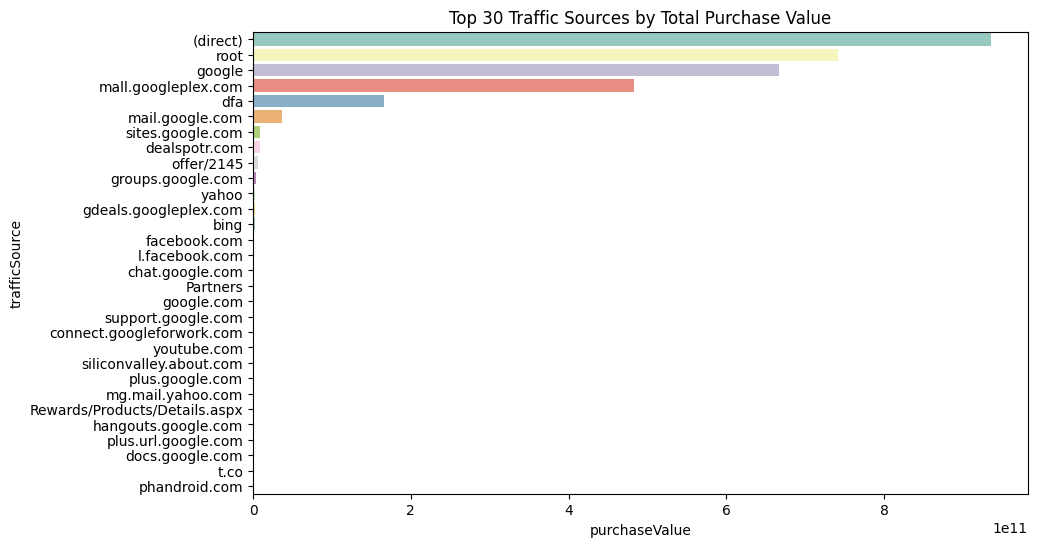

In [28]:
fig2, ax2 = plt.subplots(figsize=(10, 6))
traffic_source = train_v8.groupby('trafficSource')['purchaseValue'].sum().reset_index().sort_values(by='purchaseValue', ascending=False).head(30)
sns.barplot(data=traffic_source, x='purchaseValue', y='trafficSource', ax=ax2, palette='Set3')
ax2.set_title('Top 30 Traffic Sources by Total Purchase Value')
fig2.savefig("purchase_by_traffic_source.png", dpi=300, bbox_inches="tight")

### Plot 3 (Total Purchase Value by trafficSource.medium)

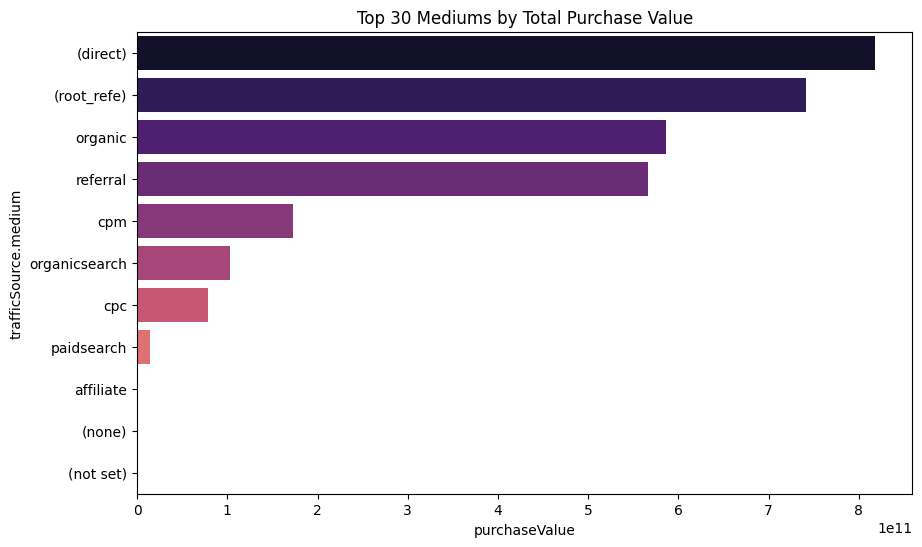

In [29]:
fig3, ax3 = plt.subplots(figsize=(10, 6))
traffic_medium = train_v8.groupby('trafficSource.medium')['purchaseValue'].sum().reset_index().sort_values(by='purchaseValue', ascending=False).head(30)
sns.barplot(data=traffic_medium, x='purchaseValue', y='trafficSource.medium', ax=ax3, palette='magma')
ax3.set_title('Top 30 Mediums by Total Purchase Value')
fig3.savefig("purchase_by_traffic_medium.png", dpi=300, bbox_inches="tight")

## Extracting year, month, day and time from sessionStart

In [30]:
def extract_session_datetime_features(df):
    df_copy = df.copy()

    # Convert sessionStart from UNIX timestamp to datetime
    df_copy['sessionStart'] = pd.to_datetime(df_copy['sessionStart'], unit='s', errors='coerce')

    # Extract basic datetime features
    df_copy['session.Year'] = df_copy['sessionStart'].dt.year
    df_copy['session.MonthYear'] = df_copy['sessionStart'].dt.strftime('%Y%m').astype(int)
    df_copy['session.Day'] = df_copy['sessionStart'].dt.day
    df_copy['session.Hour'] = df_copy['sessionStart'].dt.hour
    df_copy['session.Minute'] = df_copy['sessionStart'].dt.minute

    # Add fractional hour: e.g., 6:30 becomes 6.5
    df_copy['session.FractionalHour'] = df_copy['session.Hour'] + df_copy['session.Minute'] / 60.0

    # Drop hour and minute columns
    df_copy.drop(columns=[col for col in ['session.Hour', 'session.Minute'] if col in df_copy.columns], inplace=True)

    return df_copy

train_v9 = extract_session_datetime_features(train_v8)
test_v9 = extract_session_datetime_features(test_v8)

## Converting boolean to binary

In [31]:
train_v9['trafficSource.isTrueDirect'] = train_v9['trafficSource.isTrueDirect'].fillna(0).astype(int)
test_v9['trafficSource.isTrueDirect'] = test_v9['trafficSource.isTrueDirect'].fillna(0).astype(int)

In [32]:
# For train
train_v9.loc[train_v9['pageViews'] == 1, 'totals.bounces'] = 1

# For test
test_v9.loc[test_v9['pageViews'] == 1, 'totals.bounces'] = 1

### isMobile = 1 for mobile 

### isTablet = 1 for tablet 

### isDesktop = 1 for desktop users, else 0

In [33]:
def add_device_type_flags(df):
    df_copy = df.copy()

    # Create binary flags based on 'deviceType'
    df_copy['device_isMobile'] = (df_copy['deviceType'] == 'mobile').astype(int)
    df_copy['device_isTablet'] = (df_copy['deviceType'] == 'tablet').astype(int)
    df_copy['device_isDesktop'] = (df_copy['deviceType'] == 'desktop').astype(int)

    # Drop original columns from the copy, not external variables
    df_copy.drop(columns=['deviceType', 'device.isMobile'], inplace=True, errors='ignore')

    return df_copy

train_v10 = add_device_type_flags(train_v9)
test_v10 = add_device_type_flags(test_v9)

### Filling 'NaN's' with '0's

In [34]:
train_v10.fillna(0, inplace=True)
test_v10.fillna(0, inplace=True)

In [35]:
train_v10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 38 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   trafficSource.isTrueDirect                    116023 non-null  int64         
 1   purchaseValue                                 116023 non-null  float64       
 2   browser                                       116023 non-null  object        
 3   trafficSource.adContent                       116023 non-null  object        
 4   trafficSource.keyword                         116023 non-null  object        
 5   geoCluster                                    116023 non-null  object        
 6   trafficSource.adwordsClickInfo.slot           116023 non-null  object        
 7   userId                                        116023 non-null  int64         
 8   trafficSource.campaign                        116023 n

### Imputing city by country when city has 'not available in demo dataset'

In [36]:
def impute_city_by_country(train_df, test_df, city_col='geoNetwork.city', country_col='locationCountry'):
    """
    Replaces 'not available in demo dataset' in geoNetwork.city with the most common city per country (based on training data).
    Applies to both train and test.
    """
    # Get the most frequent city per country from train
    most_common_city = (
        train_df[train_df[city_col] != 'not available in demo dataset']
        .groupby(country_col)[city_col]
        .agg(lambda x: x.mode().iloc[0])
        .to_dict()
    )

    # Define a function to apply row-wise
    def replace_city(row):
        if row[city_col] == 'not available in demo dataset':
            return most_common_city.get(row[country_col], row[city_col])
        else:
            return row[city_col]

    # Apply to both train and test
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df[city_col] = train_df.apply(replace_city, axis=1)
    test_df[city_col] = test_df.apply(replace_city, axis=1)

    return train_df, test_df

train_v11, test_v11 = impute_city_by_country(train_v10, test_v10)

## Rank encoding in ascending order (higher mean gets higher rank)


In [37]:
def rank_encode_by_purchase_mean(train_df, test_df, cat_cols, target='purchaseValue'):
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()

    for col in cat_cols:
        # Compute purchase mean per category in train
        purchase_mean = train_encoded.groupby(col)[target].mean()

        # Rank in ascending order (higher mean gets higher rank)
        ranked = purchase_mean.sort_values(ascending=False).reset_index()
        ranked['rank'] = range(1, len(ranked) + 1)
        rank_map = ranked.set_index(col)['rank'].to_dict()

        # Map rank to both train and test
        train_encoded[f'{col}_rank'] = train_encoded[col].map(rank_map).fillna(-1).astype(int)
        test_encoded[f'{col}_rank'] = test_encoded[col].map(rank_map).fillna(-1).astype(int)

        # Drop original column
        train_encoded.drop(columns=col, inplace=True)
        test_encoded.drop(columns=col, inplace=True)

    return train_encoded, test_encoded

# List of categorical columns to encode
categorical_cols = [
    'trafficSource.campaign','trafficSource.adContent','trafficSource.keyword',
    'trafficSource.referralPath','trafficSource.medium','trafficSource',
    'userChannel','os','browser','locationCountry','geoNetwork.city','geoNetwork.subContinent',
    'geoNetwork.continent','trafficSource.adwordsClickInfo.adNetworkType',
    'trafficSource.adwordsClickInfo.page','geoCluster','geoNetwork.networkDomain',
]

# Apply encoding
train_v12, test_v12 = rank_encode_by_purchase_mean(train_v11, test_v11, categorical_cols)

### Filling totals.visits by traffic source count/frequency

In [38]:
def fill_visits_with_source_frequency(train_df, test_df, source_col='trafficSource_rank', target_col='totals.visits'):
    """
    Replace the 'totals.visits' column with the frequency (count) of each 'trafficSource' 
    based on the training data. Applies to both train and test.
    """
    # Compute frequency counts from training data
    source_counts = train_df[source_col].value_counts().to_dict()
    
    # Copy to avoid modifying originals
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Impute visits in train and test using traffic source counts
    train_df[target_col] = train_df[source_col].map(source_counts).fillna(0).astype(int)
    test_df[target_col] = test_df[source_col].map(source_counts).fillna(0).astype(int)

    return train_df, test_df

train_v13, test_v13 = fill_visits_with_source_frequency(train_v12, test_v12)

### Bounce rate across os, browser and cities

In [39]:
def compute_individual_bounce_rates(train_df, test_df, cols, bounce_col='totals.bounces'):
    train_copy = train_df.copy()
    test_copy = test_df.copy()

    for col in cols:
        # Group bounce stats in train
        bounce_stats = train_copy.groupby(col)[bounce_col].agg(
            total_sessions='count',
            total_bounces='sum'
        ).reset_index()

        bounce_stats['bounce_rate'] = bounce_stats['total_bounces'] / bounce_stats['total_sessions']

        # Rename the column
        bounce_col_name = f"{col}_bounce_rate"

        # Merge to train and test
        train_copy = train_copy.merge(
            bounce_stats[[col, 'bounce_rate']],
            on=col, how='left'
        ).rename(columns={'bounce_rate': bounce_col_name})

        test_copy = test_copy.merge(
            bounce_stats[[col, 'bounce_rate']],
            on=col, how='left'
        ).rename(columns={'bounce_rate': bounce_col_name})

        # Fill unseen values in test
        train_copy[bounce_col_name] = train_copy[bounce_col_name].fillna(0)
        test_copy[bounce_col_name] = test_copy[bounce_col_name].fillna(0)

    return train_copy, test_copy

cols = ['os_rank','browser_rank','geoNetwork.city_rank']

train_v14, test_v14 = compute_individual_bounce_rates(train_v13, test_v13, cols)

### Average Pageviews by country, subContinent and trafficSource

In [40]:
def add_avg_pageviews_per_column(train_df, test_df, group_cols, value_col='pageViews', prefix='avgPageViewsBy'):
    train_df = train_df.copy()
    test_df = test_df.copy()

    global_mean = train_df[value_col].mean()

    for col in group_cols:
        mean_map = train_df.groupby(col)[value_col].mean().to_dict()
        new_col = f"{prefix}_{col}"

        train_df[new_col] = train_df[col].map(mean_map)
        test_df[new_col] = test_df[col].map(mean_map)

        # Fill missing values with global mean
        train_df[new_col] = train_df[new_col].fillna(global_mean)
        test_df[new_col] = test_df[new_col].fillna(global_mean)

    return train_df, test_df

train_v15, test_v15 = add_avg_pageviews_per_column(
    train_v14,
    test_v14,
    group_cols=['locationCountry_rank', 'geoNetwork.subContinent_rank', 'trafficSource_rank'],
    value_col='pageViews',
    prefix='avgPageViewsBy'
)

### Avg monthly purchase value by user

In [41]:
def avg_monthly_user_purchase(train_df, test_df, user_col='userId', date_col='session.MonthYear', target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()

    # Compute total monthly purchaseValue per user
    monthly_purchase = (
        train.groupby([user_col, date_col])[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: 'avg_monthly_user_purchase'})
    )

    # Merge into train
    train = train.merge(monthly_purchase, on=[user_col, date_col], how='left')

    # Merge into test
    test = test.merge(monthly_purchase, on=[user_col, date_col], how='left')

    # Fill NaNs in test (no past purchase) with 0
    test['avg_monthly_user_purchase'] = test['avg_monthly_user_purchase'].fillna(0)

    return train, test

train_v16, test_v16 = avg_monthly_user_purchase(train_v15, test_v15, user_col='userId', date_col='session.MonthYear')

### Avg purchase value by trafficSource 

In [42]:
def compute_avg_purchase_by_traffic(train_df, test_df, source_col='trafficSource_rank', target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()
    
    # Compute mean purchaseValue per traffic source from train data
    avg_df = (
        train.groupby(source_col)[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: 'traffic_source_avg_purchase'})
    )

    # Merge into train and test
    train = train.merge(avg_df, on=source_col, how='left')
    test = test.merge(avg_df, on=source_col, how='left')

    # Fill NaNs in test (unseen traffic sources) with 0
    test['traffic_source_avg_purchase'] = test['traffic_source_avg_purchase'].fillna(0)

    return train, test

train_v16, test_v16 = compute_avg_purchase_by_traffic(train_v16, test_v16, source_col='trafficSource_rank')

### Avg purchase by browser & os combained

In [43]:
def compute_avg_purchase_by_browser_os(train_df, test_df,
                                       browser_col='browser_rank',
                                       os_col='os_rank',
                                       target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()

    # Compute average purchaseValue for each browser + OS combination
    combo_avg = (
        train.groupby([browser_col, os_col])[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: 'avg_purchase_by_browser_os'})
    )

    # Merge into train
    train = train.merge(combo_avg, on=[browser_col, os_col], how='left')

    # Merge into test
    test = test.merge(combo_avg, on=[browser_col, os_col], how='left')

    # Fill NaNs in test (unseen combinations) with 0
    test['avg_purchase_by_browser_os'] = test['avg_purchase_by_browser_os'].fillna(0)

    return train, test

train_v17, test_v17 = compute_avg_purchase_by_browser_os(train_v16, test_v16,
                                                         browser_col='browser_rank',
                                                         os_col='os_rank')

### Avg purchase by browser & city combained

In [44]:
def compute_avg_purchase_by_browser_city(train_df, test_df,
                                       browser_col='browser_rank',
                                       city_col='geoNetwork.city_rank',
                                       target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()

    # Compute average purchaseValue for each browser + city combination
    combo_avg = (
        train.groupby([browser_col, city_col])[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: 'avg_purchase_by_browser_city'})
    )

    # Merge into train
    train = train.merge(combo_avg, on=[browser_col, city_col], how='left')

    # Merge into test
    test = test.merge(combo_avg, on=[browser_col, city_col], how='left')

    # Fill NaNs in test (unseen combinations) with 0
    test['avg_purchase_by_browser_city'] = test['avg_purchase_by_browser_city'].fillna(0)

    return train, test

train_v18, test_v18 = compute_avg_purchase_by_browser_city(train_v17, test_v17,
                                                         browser_col='browser_rank',
                                                         city_col='geoNetwork.city_rank')

### Purchase History count by trafficSource

In [45]:
def add_trSource_purchase_history_count(train_df, test_df, trsource_col='trafficSource_rank', target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()

    # Count number of non-zero purchases per user in training set
    purchase_counts = (
        train[train[target_col] > 0]
        .groupby(trsource_col)
        .size()
        .reset_index(name='trSource_purchase_history_count')
    )

    # Merge with train and test
    train = train.merge(purchase_counts, on=trsource_col, how='left')
    test = test.merge(purchase_counts, on=trsource_col, how='left')

    # Fill NaN for users with no prior purchases
    train['trSource_purchase_history_count'] = train['trSource_purchase_history_count'].fillna(0).astype(int)
    test['trSource_purchase_history_count'] = test['trSource_purchase_history_count'].fillna(0).astype(int)

    return train, test

train_v19, test_v19 = add_trSource_purchase_history_count(train_v18, test_v18)

### Purchase History count by country

In [46]:
def add_country_purchase_history_count(train_df, test_df, cont_col='locationCountry_rank', target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()

    # Count number of non-zero purchases per user in training set
    purchase_counts = (
        train[train[target_col] > 0]
        .groupby(cont_col)
        .size()
        .reset_index(name='country_purchase_history_count')
    )

    # Merge with train and test
    train = train.merge(purchase_counts, on=cont_col, how='left')
    test = test.merge(purchase_counts, on=cont_col, how='left')

    # Fill NaN for users with no prior purchases
    train['country_purchase_history_count'] = train['country_purchase_history_count'].fillna(0).astype(int)
    test['country_purchase_history_count'] = test['country_purchase_history_count'].fillna(0).astype(int)

    return train, test

train_v19, test_v19 = add_country_purchase_history_count(train_v19, test_v19)

In [47]:
def compute_channel_rank_city_avg_purchase(train_df, test_df,
                                           channel_rank_col='userChannel_rank',
                                           city_col='geoNetwork.city_rank',
                                           target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()

    # Filter Direct (rank 1) and Rank 2 users
    direct_train = train[train[channel_rank_col] == 1]
    rank2_train = train[train[channel_rank_col] == 2]

    # Compute average purchase by city for Direct users
    direct_avg = (
        direct_train.groupby(city_col)[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: 'direct_city_avg_purchase'})
    )

    # Compute average purchase by city for Rank 2 users
    rank2_avg = (
        rank2_train.groupby(city_col)[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: 'rank2_city_avg_purchase'})
    )

    # Merge into train and test
    train = train.merge(direct_avg, on=city_col, how='left')
    train = train.merge(rank2_avg, on=city_col, how='left')
    test = test.merge(direct_avg, on=city_col, how='left')
    test = test.merge(rank2_avg, on=city_col, how='left')

    # Fill NaNs (for cities with no such users) with 0
    train[['direct_city_avg_purchase', 'rank2_city_avg_purchase']] = train[['direct_city_avg_purchase', 'rank2_city_avg_purchase']].fillna(0)
    test[['direct_city_avg_purchase', 'rank2_city_avg_purchase']] = test[['direct_city_avg_purchase', 'rank2_city_avg_purchase']].fillna(0)

    return train, test

train_v20, test_v20 = compute_channel_rank_city_avg_purchase(train_v19, test_v19)

In [48]:
def compute_medium_rank1_city_avg_purchase(train_df, test_df,
                                           medium_col='trafficSource.medium_rank',
                                           city_col='geoNetwork.city_rank',
                                           target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()

    # Filter for medium_rank == 1
    medium1_train = train[train[medium_col] == 1]

    # Compute average purchase by city for medium_rank 1
    medium1_avg = (
        medium1_train.groupby(city_col)[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: 'medium1_city_avg_purchase'})
    )

    # Merge into train and test
    train = train.merge(medium1_avg, on=city_col, how='left')
    test = test.merge(medium1_avg, on=city_col, how='left')

    # Fill NaNs (for cities not in medium_rank 1) with 0
    train['medium1_city_avg_purchase'] = train['medium1_city_avg_purchase'].fillna(0)
    test['medium1_city_avg_purchase'] = test['medium1_city_avg_purchase'].fillna(0)

    return train, test

train_v21, test_v21 = compute_medium_rank1_city_avg_purchase(train_v20, test_v20)

## Avg purchase by country

In [49]:
def compute_avg_purchase_by_country(train_df, test_df, source_col='locationCountry_rank', target_col='purchaseValue'):
    train = train_df.copy()
    test = test_df.copy()
    
    # Compute mean purchaseValue by country from train data
    avg_df = (
        train.groupby(source_col)[target_col]
        .mean()
        .reset_index()
        .rename(columns={target_col: 'country_avg_purchase'})
    )

    # Merge into train and test
    train = train.merge(avg_df, on=source_col, how='left')
    test = test.merge(avg_df, on=source_col, how='left')

    # Fill NaNs in test (unseen country) with 0
    test['country_avg_purchase'] = test['country_avg_purchase'].fillna(0)

    return train, test

train_v22, test_v22 = compute_avg_purchase_by_country(train_v21, test_v21, source_col='locationCountry_rank')

## Align columns and append purchaseValue at the end

In [50]:
# Get list of columns except 'purchaseValue'
cols = [col for col in train_v22.columns if col != 'purchaseValue']

# Add 'purchaseValue' at the end
cols.append('purchaseValue')

# Reorder columns in the DataFrame
train_v22 = train_v22[cols]

# Get train columns except 'purchaseValue'
train_cols = [col for col in train_v22.columns if col != 'purchaseValue']

# Reorder test columns to match train
test_v22 = test_v22[train_cols]

## user channel plus campaign total hits agregation

In [51]:
def add_totalhits_campaign_userchannel(train_df, test_df,
                                       camp_col='trafficSource.campaign_rank',
                                       user_col='userChannel_rank',
                                       target_col='totalHits'):
    train = train_df.copy()
    test = test_df.copy()

    # Compute average purchaseValue for each browser + city combination
    combo_avg = (
        train.groupby([camp_col, user_col])[target_col]
        .sum()
        .reset_index()
        .rename(columns={target_col: 'totalHits_by_user_camp'})
    )

    # Merge into train
    train = train.merge(combo_avg, on=[camp_col, user_col], how='left')

    # Merge into test
    test = test.merge(combo_avg, on=[camp_col, user_col], how='left')

    # Fill NaNs in test (unseen combinations) with 0
    test['totalHits_by_user_camp'] = test['totalHits_by_user_camp'].fillna(0)

    return train, test

train_v22, test_v22 = add_totalhits_campaign_userchannel(train_v22, test_v22,
                                                         camp_col='trafficSource.campaign_rank',
                                                         user_col='userChannel_rank')

## Correlation plot

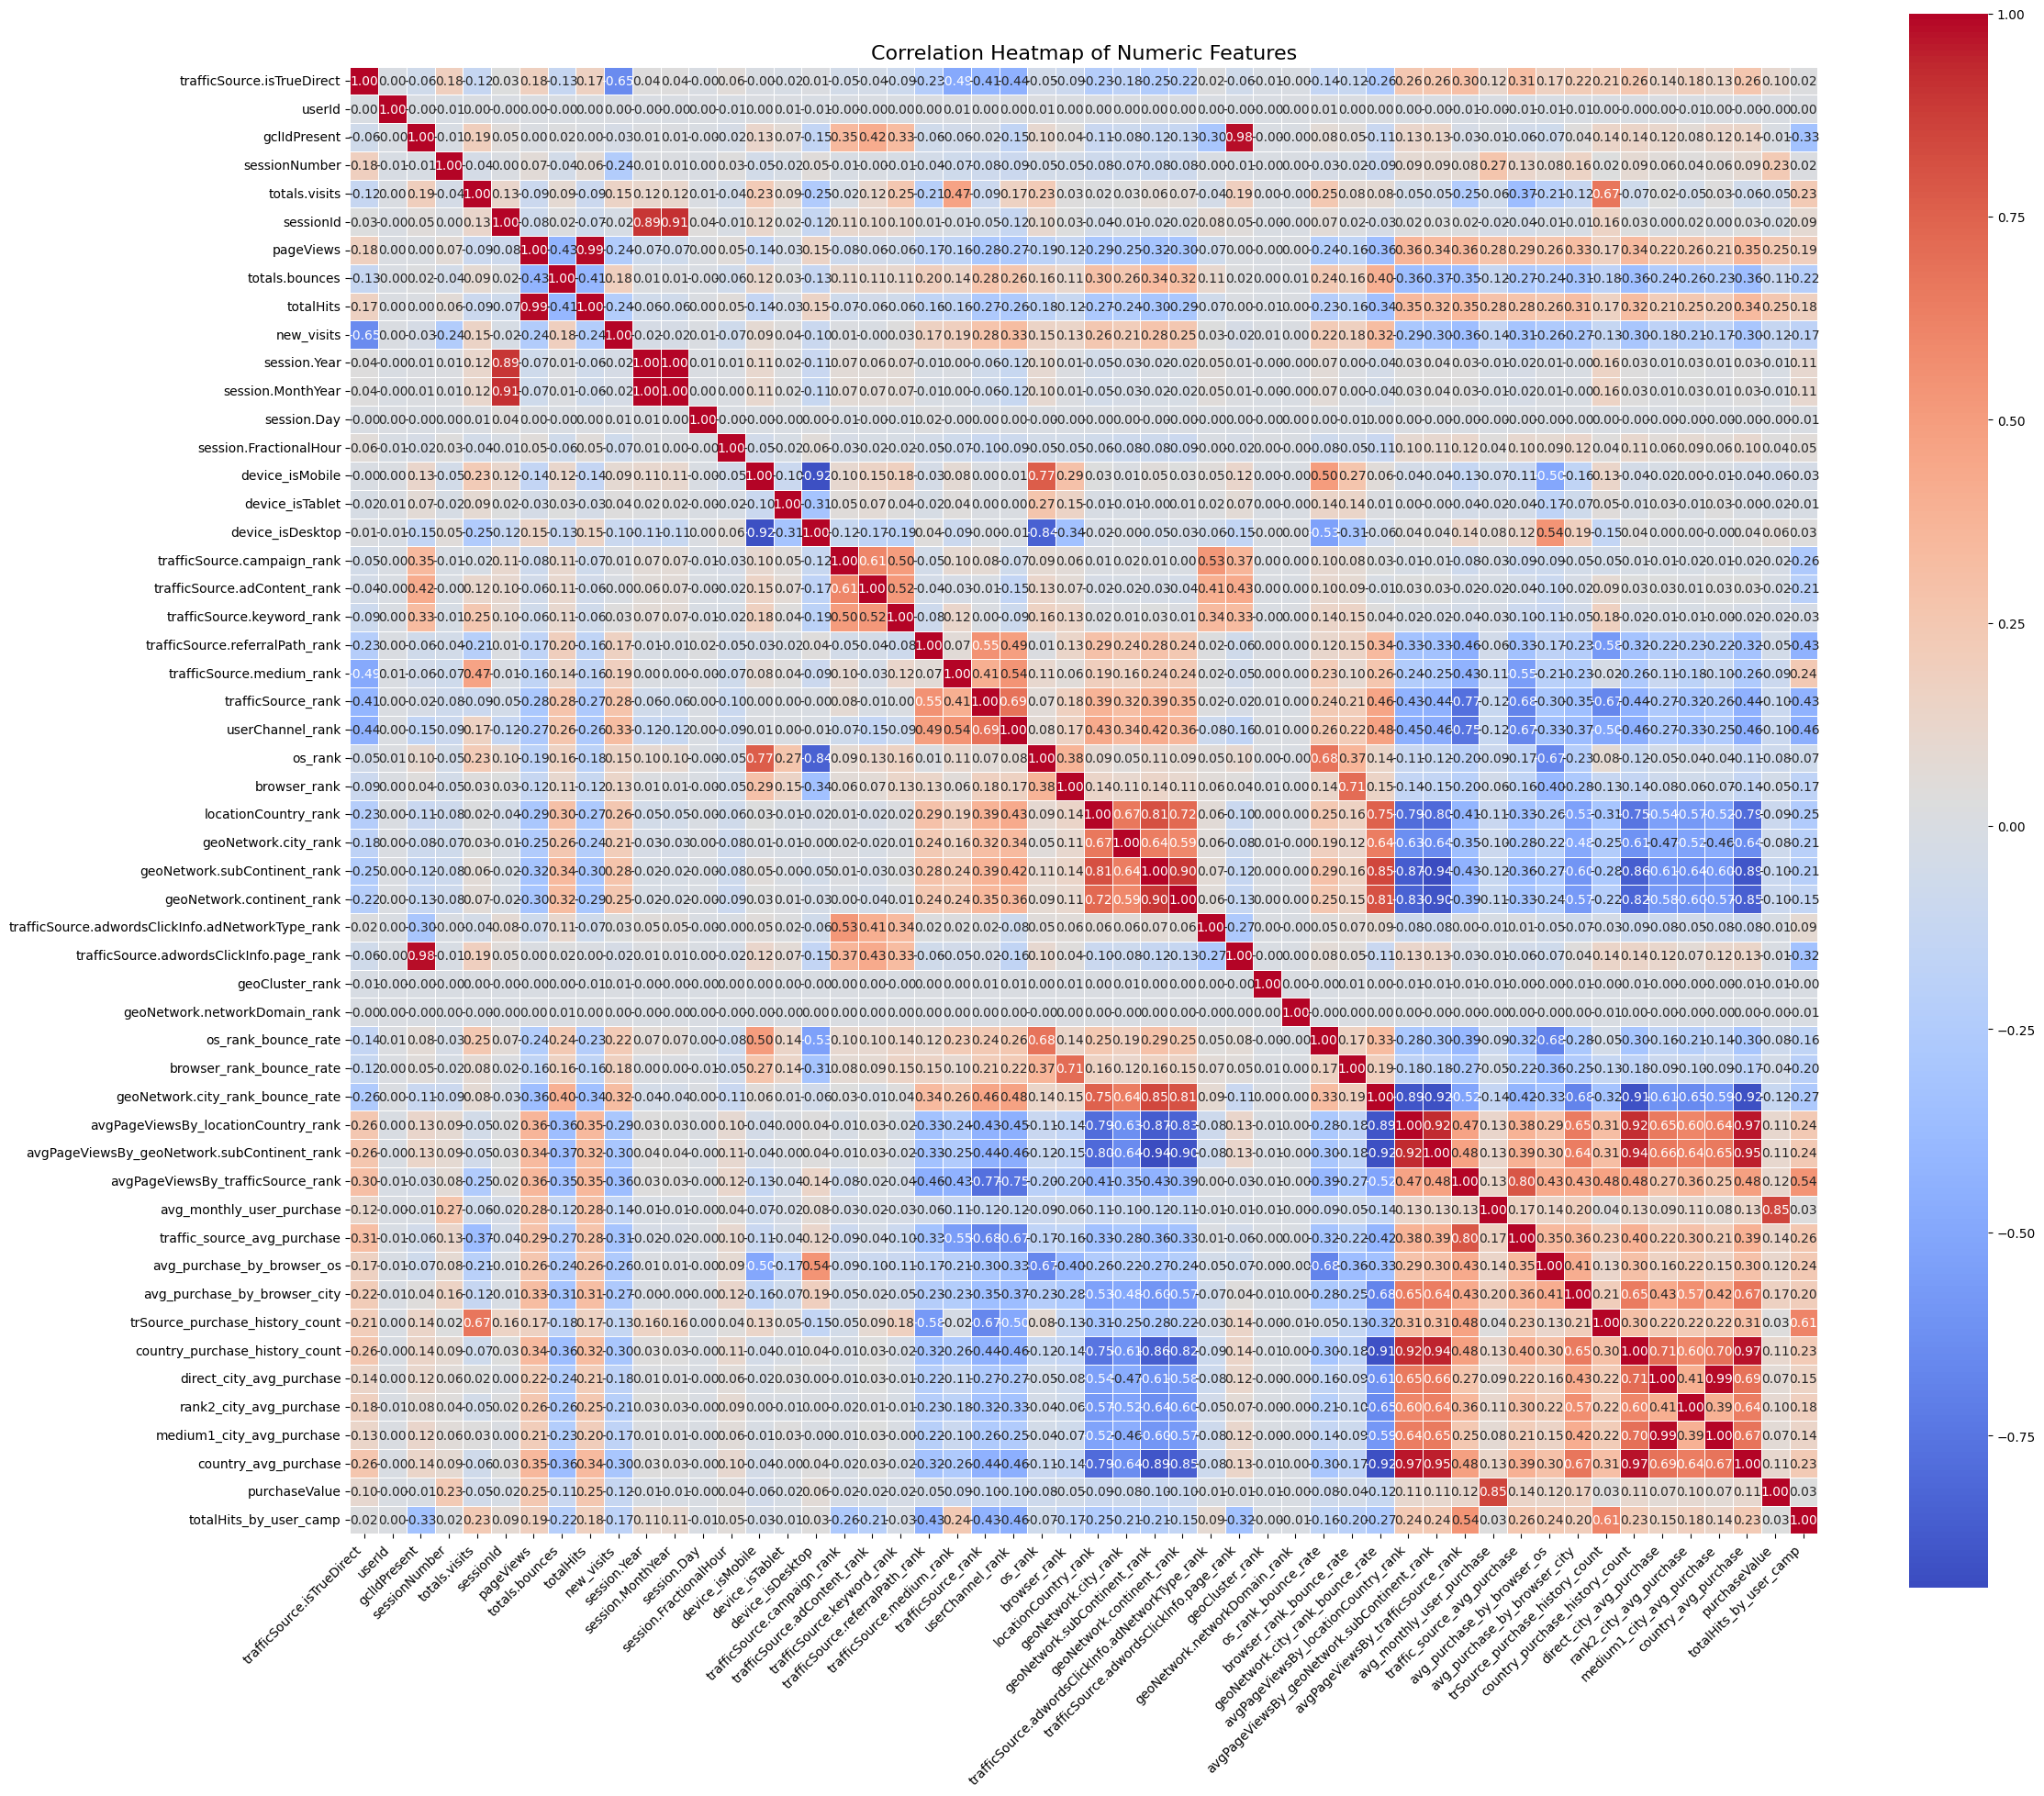

In [52]:
# Select only numeric columns
numeric_cols = train_v22.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
# from sklearn.preprocessing import MinMaxScaler

# rank_cols = ['sessionNumber','sessionId','pageViews','totalHits',
#                       'trafficSource.campaign_rank','avg_monthly_user_purchase',
#                       'trafficSource.keyword_rank','trafficSource.referralPath_rank','trafficSource.medium_rank',
#                       'os_rank','browser_rank','locationCountry_rank','geoNetwork.city_rank','avg_purchase_by_browser_city',
#                       'geoNetwork.city_rank_bounce_rate','trafficSource.adwordsClickInfo.adNetworkType_rank',
#                       'traffic_source_avg_purchase','avg_purchase_by_browser_os',
#                       'trafficSource.adwordsClickInfo.page_rank','total_totalHits_per_user_source',
#                       'userId_bounce_rate','os_rank_bounce_rate','browser_rank_bounce_rate',
#                       'locationCountry_rank_bounce_rate','campaign_success_ratio','user_purchase_history_count']

# scaler = MinMaxScaler()

# train_v18[rank_cols] = scaler.fit_transform(train_v18[rank_cols])
# test_v18[rank_cols] = scaler.transform(test_v18[rank_cols])

# Model

In [54]:
nums = train_v22.select_dtypes(include='number')
nums.columns

Index(['trafficSource.isTrueDirect', 'userId', 'gclIdPresent', 'sessionNumber',
       'totals.visits', 'sessionId', 'pageViews', 'totals.bounces',
       'totalHits', 'new_visits', 'session.Year', 'session.MonthYear',
       'session.Day', 'session.FractionalHour', 'device_isMobile',
       'device_isTablet', 'device_isDesktop', 'trafficSource.campaign_rank',
       'trafficSource.adContent_rank', 'trafficSource.keyword_rank',
       'trafficSource.referralPath_rank', 'trafficSource.medium_rank',
       'trafficSource_rank', 'userChannel_rank', 'os_rank', 'browser_rank',
       'locationCountry_rank', 'geoNetwork.city_rank',
       'geoNetwork.subContinent_rank', 'geoNetwork.continent_rank',
       'trafficSource.adwordsClickInfo.adNetworkType_rank',
       'trafficSource.adwordsClickInfo.page_rank', 'geoCluster_rank',
       'geoNetwork.networkDomain_rank', 'os_rank_bounce_rate',
       'browser_rank_bounce_rate', 'geoNetwork.city_rank_bounce_rate',
       'avgPageViewsBy_locationCou

In [55]:
numerical_features = ['trafficSource.isTrueDirect','sessionNumber','pageViews',
                      'totalHits','session.MonthYear','avg_monthly_user_purchase','totals.visits',
                      'session.Day','session.FractionalHour','device_isMobile','device_isTablet','country_avg_purchase',
                      'device_isDesktop','trafficSource.campaign_rank','medium1_city_avg_purchase',
                      'trafficSource.referralPath_rank','trafficSource.medium_rank','country_purchase_history_count',
                      'os_rank','browser_rank','avgPageViewsBy_locationCountry_rank','locationCountry_rank',
                      'geoNetwork.city_rank','avg_purchase_by_browser_city','geoNetwork.city_rank_bounce_rate',
                      'avgPageViewsBy_geoNetwork.subContinent_rank','trafficSource.adwordsClickInfo.adNetworkType_rank',
                      'traffic_source_avg_purchase','avg_purchase_by_browser_os','direct_city_avg_purchase',
                      'avgPageViewsBy_trafficSource_rank','os_rank_bounce_rate','browser_rank_bounce_rate',
                      'rank2_city_avg_purchase','trSource_purchase_history_count','totalHits_by_user_camp']

In [56]:
X = train_v22[numerical_features]
y = train_v22['purchaseValue']
X_test = test_v22[numerical_features]

# MODELS

# 1. XGBRegressor (On Validation Set)


In [57]:
# Stratified split
df = train_v22.copy()
df['strata'] = pd.qcut(df['purchaseValue'], q=10, duplicates='drop')
train_df, val_df = train_test_split(df, test_size=0.25, random_state=42, stratify=df['strata'])
train_df.drop(columns=['strata'], inplace=True)
val_df.drop(columns=['strata'], inplace=True)

# Features and targets
features = numerical_features
X_train = train_df[features]
y_train = train_df['purchaseValue']
X_val = val_df[features]
y_val = val_df['purchaseValue']

# XGBoost model
xgb = XGBRegressor(random_state=42, n_estimators = 51, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)

# Predict and evaluate
y_val_pred_xgb = xgb.predict(X_val)
r2_xgb = r2_score(y_val, y_val_pred_xgb)
print(f"XGBoost R² score on validation set: {r2_xgb:.5f}")

# Predict on test
y_pred_xgb = xgb.predict(X_test)

# Clipping the negetive predicted values
y_pred_xgb = np.maximum(0, xgb.predict(X_test))

XGBoost R² score on validation set: 0.70538


### On test public score (XGB) : 0.35252

# 2. LightGBM Regressor (On Validation Set)

In [58]:
# Stratified split
df = train_v22.copy()
df['strata'] = pd.qcut(df['purchaseValue'], q=10, duplicates='drop')
train_df, val_df = train_test_split(df, test_size=0.25, random_state=42, stratify=df['strata'])
train_df.drop(columns=['strata'], inplace=True)
val_df.drop(columns=['strata'], inplace=True)

# Features and targets
features = numerical_features
X_train = train_df[features]
y_train = train_df['purchaseValue']
X_val = val_df[features]
y_val = val_df['purchaseValue']

# LightGBM model
lgb = LGBMRegressor(random_state=42, n_estimators=201, n_jobs=-1)
lgb.fit(X_train, y_train)

# Predict and evaluate
y_val_pred_lgb = lgb.predict(X_val)
r2_lgb = r2_score(y_val, y_val_pred_lgb)
print(f"LightGBM R² score on validation set: {r2_lgb:.5f}")

# Predict on test
y_pred_lgb = lgb.predict(X_test)

# Clipping the negetive predicted values
y_pred_lgb = np.maximum(0, lgb.predict(X_test))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009806 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2872
[LightGBM] [Info] Number of data points in the train set: 87017, number of used features: 36
[LightGBM] [Info] Start training from score 25892354.133468
LightGBM R² score on validation set: 0.59288


### On test public score (LGBM) : 0.28261

# 3. RandomForestRegressor (On Validation Set)

In [59]:
df = train_v22.copy()

df['strata'] = pd.qcut(df['purchaseValue'], q=10, duplicates='drop')

train_df, val_df = train_test_split(df, test_size=0.25, random_state=42, stratify=df['strata'])

train_df.drop(columns=['strata'], inplace=True)
val_df.drop(columns=['strata'], inplace=True)

features = numerical_features

X_train = train_df[features]
y_train = train_df['purchaseValue']

X_val = val_df[features]
y_val = val_df['purchaseValue']

model = RandomForestRegressor(random_state=42, n_estimators=196, n_jobs=-1)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)
r2 = r2_score(y_val, y_val_pred)

print(f"R² score on validation set: {r2:.5f}")

# Predict on test
y_pred_rf = model.predict(X_test)

R² score on validation set: 0.74657


### On test public score (RFR - Without_log_Tr) : 0.50941

## 3(1). Log transforming the target column and predicting on test set

In [60]:
# Log-transform the target
y_log = np.log1p(y)

# Train the model on log-transformed target
model.fit(X, y_log)

# Predict on training data and invert
y_pred_log_tr = model.predict(X)
y_pred_tr = np.expm1(y_pred_log_tr)

# Evaluate
r2_rf = r2_score(y, y_pred_tr)
print(f"Random Forest R² (Train, log-inverted): {r2_rf:.5f}")

# Predict on test and invert
y_pred_log_rf = model.predict(X_test)
y_pred_rfr = np.expm1(y_pred_log_rf)

Random Forest R² (Train, log-inverted): 0.82725


### On test public score (RFR - With log_Tr) : 0.61564 -> This this less than that of my high R2 score till now because I dropped sessionId from it, since it had high cardinality and high correlation with other two features which I engineered.

In [61]:
submission = pd.DataFrame({
    'id':range(len(test_v22)),
    'purchaseValue':y_pred_rfr
})
submission.to_csv('submission.csv', index=False)

In [62]:
submission

,id,purchaseValue
0,0,3.425059e+07
1,1,0.000000e+00
2,2,0.000000e+00
3,3,5.516209e-01
4,4,0.000000e+00
...,...,...
29001,29001,0.000000e+00
29002,29002,1.440225e+08
29003,29003,4.849733e+07
29004,29004,0.000000e+00


In [63]:
print((submission['purchaseValue'].gt(0).value_counts().rename({True: 'Non-zero', False: 'Zero'})))

purchaseValue
Zero        24797
Non-zero     4209
Name: count, dtype: int64


## Hyper Parameter Tuning

In [64]:
# # Parameter grid
# param_dist = {
#     'n_estimators': [100, 150, 200, 250, 300],
#     'max_depth': [5, 10, 15, 20, 25, 30, None],
#     'min_samples_split': [2, 4, 6, 8, 10],
#     'min_samples_leaf': [1, 2, 3, 4, 5],
#     'max_features': ['auto', 'sqrt', 'log2']
# }

# # Model
# rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# # Set up RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=50,  # Total combinations to try
#     scoring='r2',
#     cv=3,
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# # Fit on training data
# random_search.fit(X_train, y_train)

# # Predict and evaluate
# y_pred = random_search.predict(X_val)
# r2 = r2_score(y_val, y_pred)

# # Results
# print("\nBest Parameters:")
# print(random_search.best_params_)
# print(f"Best Training CV R² Score: {random_search.best_score_:.5f}")
# print(f"Validation R² Score: {r2:.5f}")

# Model Comparison Report

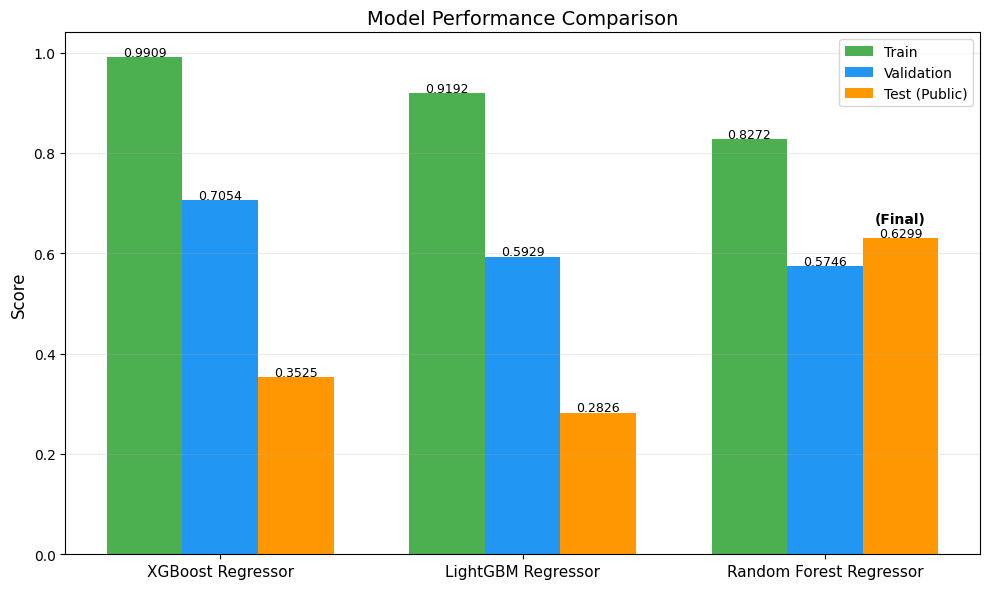

In [65]:
models = ["XGBoost Regressor", "LightGBM Regressor", "Random Forest Regressor"]

train_scores = [0.9909, 0.9192, 0.8272]       
val_scores   = [0.7054, 0.5929, 0.5746]       
test_scores  = [0.3525, 0.2826, 0.6299]    

# Bar positions
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, train_scores, width, label="Train", color="#4CAF50")
plt.bar(x,        val_scores,   width, label="Validation", color="#2196F3")
plt.bar(x + width, test_scores, width, label="Test (Public)", color="#FF9800")

# Labels & Title
plt.xticks(x, models, fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.title("Model Performance Comparison", fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.25)

# Value labels on bars
for scores, shift in [(train_scores, -width), (val_scores, 0), (test_scores, width)]:
    for i, score in enumerate(scores):
        plt.text(x[i] + shift, score + 0.003, f"{score:.4f}", ha='center', fontsize=9)

rf_index = 2  
plt.text(x[rf_index] + width, test_scores[rf_index] + 0.030,
         "(Final)", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("model_performance_comparison.png", dpi=300)
plt.show()